# Práctica 0: Análisis de Entropía en Imágenes

## Grupo de Investigación en Análisis de Información y Tratamiento Automático (GIATA)
### Universidad Politécnica Salesiana - Ecuador

---

## Introducción

Este cuaderno implementa un análisis completo de entropía en imágenes digitales. Se procesan 900 imágenes organizadas en 10 categorías, calculando su nivel de entropía en escala de grises y en color. Además, se realizan modificaciones progresivas en un conjunto de imágenes para analizar cómo varía la entropía bajo cambios deliberados.

### Objetivos
1. Calcular entropía en imágenes: escala de grises y RGB
2. Analizar variación de entropía por categoría
3. Generar visualizaciones de distribuciones (boxplots)
4. Modificar imágenes en 3 niveles de intensidad
5. Cuantificar cambios de entropía tras modificaciones
6. Generar informe HTML automatizado

---

## 1. Instalación de Dependencias

In [62]:
import subprocess
import sys

packages = [
    'scikit-image',
    'numpy',
    'matplotlib',
    'scipy',
    'pillow',
    'pandas',
    'nbconvert'
]

print("Instalando dependencias necesarias...")
for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"  {package}: ya instalado")
    except ImportError:
        print(f"  {package}: instalando...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"  {package}: instalado exitosamente")

print("\nTodas las dependencias están listas.")

Instalando dependencias necesarias...
  scikit-image: instalando...
  scikit-image: instalado exitosamente
  numpy: ya instalado
  matplotlib: ya instalado
  scipy: ya instalado
  pillow: instalando...
  pillow: instalado exitosamente
  pandas: ya instalado
  nbconvert: ya instalado

Todas las dependencias están listas.


## 2. Importación de Librerías

In [63]:
import os
import zipfile
import shutil
from pathlib import Path
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from PIL import Image, ImageDraw, ImageFilter, ImageOps
from skimage.color import rgb2gray
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3. Creación de Estructura de Carpetas

In [64]:
BASE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

FOLDERS = {
    'original': os.path.join(OUTPUT_DIR, 'images_originales'),
    'histograms': os.path.join(OUTPUT_DIR, 'histogramas'),
    'small': os.path.join(OUTPUT_DIR, 'modificaciones', 'pequenas'),
    'medium': os.path.join(OUTPUT_DIR, 'modificaciones', 'medianas'),
    'large': os.path.join(OUTPUT_DIR, 'modificaciones', 'grandes'),
    'graphics': os.path.join(OUTPUT_DIR, 'graficos'),
    'reports': os.path.join(OUTPUT_DIR, 'reportes')
}

for folder_type, folder_path in FOLDERS.items():
    os.makedirs(folder_path, exist_ok=True)
    print(f"Carpeta lista: {folder_path}")

print("\nEstructura de carpetas creada exitosamente.")

Carpeta lista: /home/jordyr/Desktop/Practica0/output/images_originales
Carpeta lista: /home/jordyr/Desktop/Practica0/output/histogramas
Carpeta lista: /home/jordyr/Desktop/Practica0/output/modificaciones/pequenas
Carpeta lista: /home/jordyr/Desktop/Practica0/output/modificaciones/medianas
Carpeta lista: /home/jordyr/Desktop/Practica0/output/modificaciones/grandes
Carpeta lista: /home/jordyr/Desktop/Practica0/output/graficos
Carpeta lista: /home/jordyr/Desktop/Practica0/output/reportes

Estructura de carpetas creada exitosamente.


## 4. Descompresión y Carga de Datos

In [65]:
ZIP_PATH = 'images_pr0.zip'
EXTRACT_PATH = os.path.join(BASE_DIR, 'images_extracted')

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"No se encontró {ZIP_PATH} en el directorio actual")

print(f"Tamaño del ZIP: {os.path.getsize(ZIP_PATH) / (1024*1024):.1f} MB")
print(f"Descomprimiendo a: {EXTRACT_PATH}...")

if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Descompresión completada.")

Tamaño del ZIP: 25.5 MB
Descomprimiendo a: /home/jordyr/Desktop/Practica0/images_extracted...
Descompresión completada.


## 5. Carga de Imágenes por Categoría

In [66]:
def load_images_by_category(extract_path):
    """Carga imágenes organizadas por categoría"""
    images_data = {}
    total_images = 0
    
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                file_path = os.path.join(root, file)
                category = os.path.basename(root)
                
                try:
                    img = Image.open(file_path).convert('RGB')
                    
                    if category not in images_data:
                        images_data[category] = []
                    
                    images_data[category].append({
                        'path': file_path,
                        'filename': file,
                        'image': img,
                        'size': img.size
                    })
                    total_images += 1
                except Exception as e:
                    print(f"Error al cargar {file}: {e}")
    
    return images_data, total_images

images_data, total_images = load_images_by_category(EXTRACT_PATH)

print(f"Total de imágenes: {total_images}")
print(f"Categorías encontradas: {len(images_data)}")
print("\nDistribución por categoría:")

for cat in sorted(images_data.keys()):
    count = len(images_data[cat])
    print(f"  {cat:35s}: {count:3d} imágenes")

Total de imágenes: 900
Categorías encontradas: 10

Distribución por categoría:
  beaches                            :  90 imágenes
  bus                                :  90 imágenes
  dinosaurs                          :  90 imágenes
  elephants                          :  90 imágenes
  flowers                            :  90 imágenes
  foods                              :  90 imágenes
  horses                             :  90 imágenes
  monuments                          :  90 imágenes
  mountains_and_snow                 :  90 imágenes
  peolpe_and_villages_in_Africa      :  90 imágenes


## 6. Marco Teórico: Entropía en Imágenes

### ¿Qué es la Entropía?

La **entropía** es una medida fundamental en teoría de la información (Shannon, 1948) que cuantifica el nivel de desorden o incertidumbre en un conjunto de datos.

**Fórmula matemática:**

$$H(X) = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

Donde:
- H(X) es la entropía
- p_i es la probabilidad de ocurrencia del valor i
- log₂ es el logaritmo base 2

### Interpretación de Valores

- **Entropía Alta (6-8 bits):** Imagen con muchos valores de píxeles diferentes, compleja, con mucho detalle y variabilidad cromática
- **Entropía Baja (0-3 bits):** Imagen uniforme, con pocos valores distintos, menos detalles

### Entropía en Escala de Grises

- Considera un único canal: intensidad de luz (0-255)
- Rango típico: 0-8 bits
- Refleja la variabilidad de luminosidad

### Entropía en Color (RGB)

- Considera tres canales: Rojo, Verde, Azul
- Se calcula la entropía de cada canal independientemente y se promedian
- Generalmente mayor que escala de grises
- Refleja la complejidad total de la imagen incluyendo componente cromática

### Diferencia: Grises vs Color

- **Escala de grises:** Reduce la imagen a una dimensión (intensidad)
- **Color (RGB):** Tres dimensiones capturan más información
- Imágenes con colores variados tendrán mayor diferencia entre ambas medidas

## 7. Funciones de Cálculo de Entropía

In [67]:
def calculate_entropy_gray(image):
    """Calcula entropía en escala de grises"""
    if isinstance(image, Image.Image):
        img_array = np.array(image)
    else:
        img_array = image
    
    img_gray = rgb2gray(img_array)
    img_gray_uint8 = (img_gray * 255).astype(np.uint8)
    
    histogram, _ = np.histogram(img_gray_uint8.flatten(), bins=256, range=(0, 256))
    probabilities = histogram / histogram.sum()
    probabilities = probabilities[probabilities > 0]
    
    entropy_value = -np.sum(probabilities * np.log2(probabilities))
    return entropy_value

def calculate_entropy_rgb(image):
    """Calcula entropía en color (RGB) - promedio de canales"""
    if isinstance(image, Image.Image):
        img_array = np.array(image)
    else:
        img_array = image
    
    entropies = []
    
    for channel_idx in range(3):
        channel = img_array[:, :, channel_idx].flatten()
        histogram, _ = np.histogram(channel, bins=256, range=(0, 256))
        probabilities = histogram / histogram.sum()
        probabilities = probabilities[probabilities > 0]
        channel_entropy = -np.sum(probabilities * np.log2(probabilities))
        entropies.append(channel_entropy)
    
    return np.mean(entropies)

test_image = images_data[list(images_data.keys())[0]][0]['image']
test_gray = calculate_entropy_gray(test_image)
test_rgb = calculate_entropy_rgb(test_image)

print(f"Funciones de entropía validadas:")
print(f"  Entropía Gray (prueba): {test_gray:.4f} bits")
print(f"  Entropía RGB (prueba):  {test_rgb:.4f} bits")

Funciones de entropía validadas:
  Entropía Gray (prueba): 7.4758 bits
  Entropía RGB (prueba):  7.5222 bits


## 8. Exploración y Visualización de Ejemplos

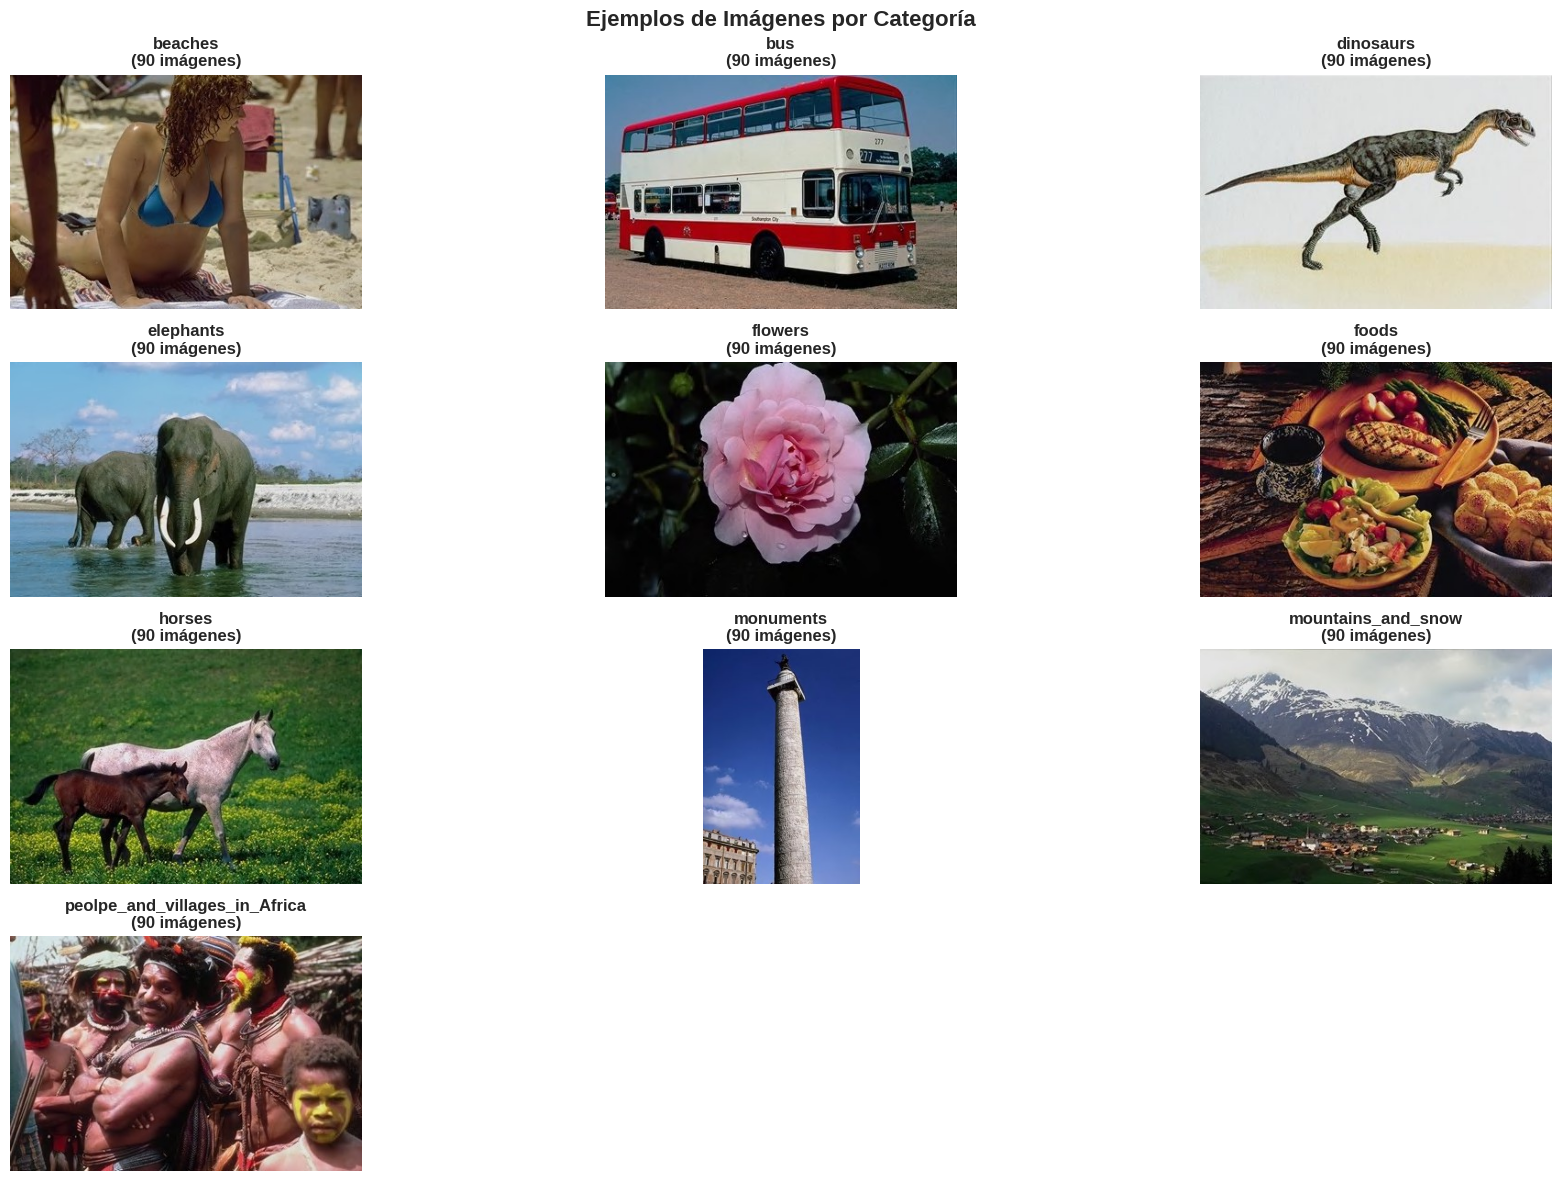

Ejemplos visualizados y guardados.


In [68]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Ejemplos de Imágenes por Categoría', fontsize=16, fontweight='bold')

categories = sorted(images_data.keys())
n_cols = 3
n_rows = (len(categories) + n_cols - 1) // n_cols

for idx, category in enumerate(categories, 1):
    ax = plt.subplot(n_rows, n_cols, idx)
    img = images_data[category][0]['image']
    filename = images_data[category][0]['filename']
    
    ax.imshow(img)
    ax.set_title(f"{category}\n({len(images_data[category])} imágenes)", fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FOLDERS['original'], 'ejemplos_por_categoria.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Ejemplos visualizados y guardados.")

## 9. Histogramas de Ejemplos

In [69]:
def save_histogram_visualization(image, category_name, filename_prefix):
    """Guarda visualización de histogramas"""
    img_array = np.array(image)
    img_gray = rgb2gray(img_array)
    img_gray_uint8 = (img_gray * 255).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(f"Histogramas - {category_name}", fontweight='bold')
    
    axes[0].hist(img_gray_uint8.flatten(), bins=256, color='gray', edgecolor='black', alpha=0.7)
    axes[0].set_title('Escala de Grises')
    axes[0].set_xlabel('Intensidad')
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(alpha=0.3)
    
    colors = ('red', 'green', 'blue')
    for i, color in enumerate(colors):
        channel = img_array[:, :, i].flatten()
        axes[1].hist(channel, bins=256, color=color, alpha=0.4, label=f"{color.upper()}")
    
    axes[1].set_title('Canales RGB')
    axes[1].set_xlabel('Intensidad')
    axes[1].set_ylabel('Frecuencia')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    filepath = os.path.join(FOLDERS['histograms'], f"{filename_prefix}_histogramas.png")
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()
    return filepath

print("Generando histogramas de ejemplos...")

for idx, category in enumerate(sorted(images_data.keys())[:3]):
    img = images_data[category][0]['image']
    filename_prefix = f"{idx+1:02d}_{category}"
    save_histogram_visualization(img, category, filename_prefix)
    print(f"  {category}: histograma guardado")

print("\nHistogramas de ejemplos generados.")

Generando histogramas de ejemplos...
  beaches: histograma guardado
  bus: histograma guardado
  dinosaurs: histograma guardado

Histogramas de ejemplos generados.


## 10. Cálculo de Entropía para Todas las Imágenes

In [70]:
entropy_results = {}

print("Calculando entropía para todas las imágenes...\n")

for category in sorted(images_data.keys()):
    entropy_results[category] = {
        'gray': [],
        'rgb': [],
        'sizes': []
    }
    
    for img_info in images_data[category]:
        try:
            img = img_info['image']
            entropy_gray = calculate_entropy_gray(img)
            entropy_rgb = calculate_entropy_rgb(img)
            
            entropy_results[category]['gray'].append(entropy_gray)
            entropy_results[category]['rgb'].append(entropy_rgb)
            entropy_results[category]['sizes'].append(img_info['size'])
        except Exception as e:
            print(f"Error en {category}: {e}")
    
    gray_mean = np.mean(entropy_results[category]['gray'])
    rgb_mean = np.mean(entropy_results[category]['rgb'])
    print(f"{category:35s} | Gray: {gray_mean:.4f} | RGB: {rgb_mean:.4f}")

print("\nCálculo completado.")

Calculando entropía para todas las imágenes...

beaches                             | Gray: 7.2148 | RGB: 7.2385
bus                                 | Gray: 7.4698 | RGB: 7.4825
dinosaurs                           | Gray: 4.7055 | RGB: 4.7930
elephants                           | Gray: 7.4377 | RGB: 7.4522
flowers                             | Gray: 6.4898 | RGB: 6.4838
foods                               | Gray: 7.3497 | RGB: 7.3144
horses                              | Gray: 7.2046 | RGB: 7.0798
monuments                           | Gray: 7.3791 | RGB: 7.3911
mountains_and_snow                  | Gray: 7.3514 | RGB: 7.3709
peolpe_and_villages_in_Africa       | Gray: 7.5160 | RGB: 7.5182

Cálculo completado.


## 11. Tabla de Estadísticas

In [71]:
stats_data = []

for category in sorted(entropy_results.keys()):
    gray_values = entropy_results[category]['gray']
    rgb_values = entropy_results[category]['rgb']
    
    stats_data.append({
        'Categoría': category,
        'Entropía Gray (Media)': np.mean(gray_values),
        'Entropía Gray (Std)': np.std(gray_values),
        'Entropía RGB (Media)': np.mean(rgb_values),
        'Entropía RGB (Std)': np.std(rgb_values),
        'Imágenes': len(gray_values)
    })

df_stats = pd.DataFrame(stats_data)

print("="*110)
print("ESTADÍSTICAS DE ENTROPÍA POR CATEGORÍA")
print("="*110)
print(df_stats.to_string(index=False))
print("="*110)

df_ranked = df_stats.sort_values('Entropía RGB (Media)', ascending=False)
print("\nRANKING: Categorías por Entropía RGB (Mayor a Menor)")
print("="*80)
for idx, row in df_ranked.iterrows():
    print(f"{idx+1:2d}. {row['Categoría']:35s} - {row['Entropía RGB (Media)']:.4f} bits")
print("="*80)

ESTADÍSTICAS DE ENTROPÍA POR CATEGORÍA
                    Categoría  Entropía Gray (Media)  Entropía Gray (Std)  Entropía RGB (Media)  Entropía RGB (Std)  Imágenes
                      beaches               7.214833             0.304457              7.238489            0.270655        90
                          bus               7.469812             0.157100              7.482515            0.150347        90
                    dinosaurs               4.705511             0.500830              4.792988            0.487948        90
                    elephants               7.437686             0.255177              7.452161            0.232302        90
                      flowers               6.489819             0.540525              6.483843            0.530310        90
                        foods               7.349673             0.447191              7.314419            0.421755        90
                       horses               7.204612             0.193058      

## 12. Boxplots por Categoría

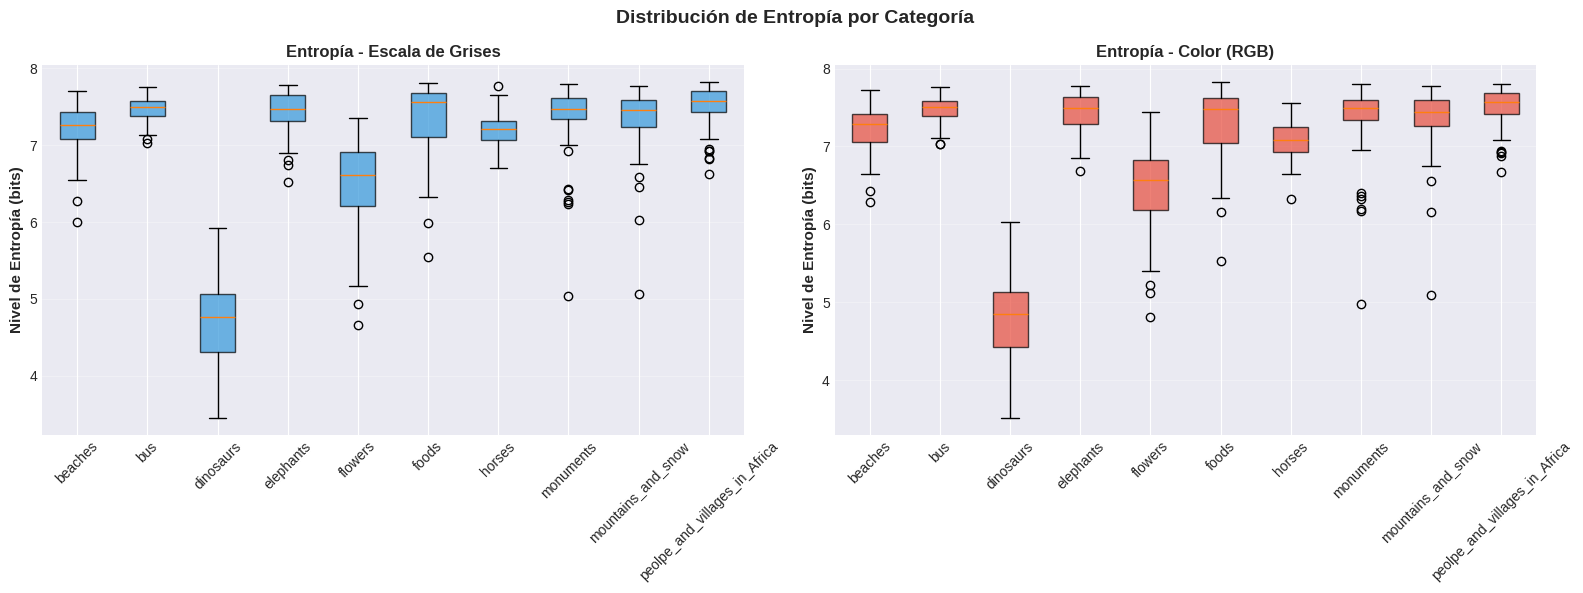

Boxplots generados y guardados.


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución de Entropía por Categoría', fontsize=14, fontweight='bold')

categories_sorted = sorted(entropy_results.keys())

gray_data = [entropy_results[cat]['gray'] for cat in categories_sorted]
bp1 = axes[0].boxplot(gray_data, labels=categories_sorted, patch_artist=True)

for patch in bp1['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.7)

axes[0].set_title('Entropía - Escala de Grises', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Nivel de Entropía (bits)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

rgb_data = [entropy_results[cat]['rgb'] for cat in categories_sorted]
bp2 = axes[1].boxplot(rgb_data, labels=categories_sorted, patch_artist=True)

for patch in bp2['boxes']:
    patch.set_facecolor('#e74c3c')
    patch.set_alpha(0.7)

axes[1].set_title('Entropía - Color (RGB)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nivel de Entropía (bits)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
boxplot_path = os.path.join(FOLDERS['graphics'], 'boxplots_por_categoria.png')
plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
plt.show()

print("Boxplots generados y guardados.")

## 13. Análisis: Categorías con Mayor Entropía

In [73]:
df_ranked = df_stats.sort_values('Entropía RGB (Media)', ascending=False)
max_entropy_cat = df_ranked.iloc[0]
min_entropy_cat = df_ranked.iloc[-1]

print("ANÁLISIS DE RESULTADOS")
print("="*80)
print(f"\n1. CATEGORÍA CON MAYOR ENTROPÍA:")
print(f"   Categoría: {max_entropy_cat['Categoría']}")
print(f"   Entropía RGB: {max_entropy_cat['Entropía RGB (Media)']:.4f} bits")
print(f"\n   Interpretación: Las imágenes de '{max_entropy_cat['Categoría']}' presentan:")
print(f"   - Mayor complejidad visual y variabilidad de colores")
print(f"   - Más detalles y texturas")
print(f"   - Mayor diversidad de tonos cromáticos")

print(f"\n2. CATEGORÍA CON MENOR ENTROPÍA:")
print(f"   Categoría: {min_entropy_cat['Categoría']}")
print(f"   Entropía RGB: {min_entropy_cat['Entropía RGB (Media)']:.4f} bits")
print(f"\n   Interpretación: Las imágenes de '{min_entropy_cat['Categoría']}' presentan:")
print(f"   - Menor complejidad visual")
print(f"   - Menos variabilidad de colores")
print(f"   - Imágenes más uniformes o simples")

print(f"\n3. DIFERENCIA RGB VS ESCALA DE GRISES:")
mean_rgb_all = df_stats['Entropía RGB (Media)'].mean()
mean_gray_all = df_stats['Entropía Gray (Media)'].mean()
print(f"   Entropía RGB promedio: {mean_rgb_all:.4f} bits")
print(f"   Entropía Gray promedio: {mean_gray_all:.4f} bits")
print(f"   Diferencia: {mean_rgb_all - mean_gray_all:+.4f} bits")
print(f"\n   Razón: RGB captura información en 3 canales (R, G, B) mientras que")
print(f"   escala de grises condensa la información en 1 solo canal.")

print("\n" + "="*80)

ANÁLISIS DE RESULTADOS

1. CATEGORÍA CON MAYOR ENTROPÍA:
   Categoría: peolpe_and_villages_in_Africa
   Entropía RGB: 7.5182 bits

   Interpretación: Las imágenes de 'peolpe_and_villages_in_Africa' presentan:
   - Mayor complejidad visual y variabilidad de colores
   - Más detalles y texturas
   - Mayor diversidad de tonos cromáticos

2. CATEGORÍA CON MENOR ENTROPÍA:
   Categoría: dinosaurs
   Entropía RGB: 4.7930 bits

   Interpretación: Las imágenes de 'dinosaurs' presentan:
   - Menor complejidad visual
   - Menos variabilidad de colores
   - Imágenes más uniformes o simples

3. DIFERENCIA RGB VS ESCALA DE GRISES:
   Entropía RGB promedio: 7.0124 bits
   Entropía Gray promedio: 7.0118 bits
   Diferencia: +0.0006 bits

   Razón: RGB captura información en 3 canales (R, G, B) mientras que
   escala de grises condensa la información en 1 solo canal.



## 14. Funciones de Modificación de Imágenes

In [74]:
def modify_image_small(image):
    """Modificación pequeña: agrega un pequeño objeto (círculo)
    Representa aproximadamente 1% de cambio"""
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)
    
    size = max(5, max(img_copy.size) // 50)
    x = img_copy.size[0] - size - 10
    y = img_copy.size[1] - size - 10
    
    draw.ellipse([x, y, x + size, y + size], fill=(255, 0, 0, 255))
    return img_copy

def modify_image_medium(image):
    """Modificación mediana: filtro suave + objeto
    Representa aproximadamente 10% de cambio"""
    img_copy = image.copy()
    img_copy = img_copy.filter(ImageFilter.GaussianBlur(radius=2))
    
    draw = ImageDraw.Draw(img_copy)
    size = max(10, max(img_copy.size) // 15)
    draw.rectangle([10, 10, 10 + size, 10 + size], fill=(0, 255, 0, 255))
    
    return img_copy

def modify_image_large(image):
    """Modificación grande: filtro fuerte + objeto grande
    Representa aproximadamente 20% de cambio"""
    img_copy = image.copy()
    img_copy = img_copy.filter(ImageFilter.EDGE_ENHANCE)
    
    draw = ImageDraw.Draw(img_copy)
    size = max(img_copy.size) // 5
    x = (img_copy.size[0] - size) // 2
    y = (img_copy.size[1] - size) // 2
    draw.rectangle([x, y, x + size, y + size], outline=(0, 0, 255, 255), width=5)
    
    return img_copy

print("Funciones de modificación definidas.")

Funciones de modificación definidas.


## 15. Aplicación de Modificaciones

In [75]:
print("Seleccionando al menos 10 imágenes para modificación...\n")

images_to_modify = []
for category in sorted(images_data.keys()):
    count_per_cat = max(1, 10 // len(images_data))
    images_to_modify.extend([
        (category, images_data[category][i])
        for i in range(min(count_per_cat, len(images_data[category])))
    ])

images_to_modify = images_to_modify[:max(10, len(images_to_modify))]
print(f"Total de imágenes a modificar: {len(images_to_modify)}")
print("Aplicando modificaciones...\n")

modifications_results = {
    'small': {'original': [], 'modified': [], 'difference': []},
    'medium': {'original': [], 'modified': [], 'difference': []},
    'large': {'original': [], 'modified': [], 'difference': []}
}

modification_functions = {
    'small': (modify_image_small, FOLDERS['small']),
    'medium': (modify_image_medium, FOLDERS['medium']),
    'large': (modify_image_large, FOLDERS['large'])
}

image_counter = 1

for mod_type, (mod_func, mod_folder) in modification_functions.items():
    for img_idx, (category, img_info) in enumerate(images_to_modify, 1):
        original_img = img_info['image']
        modified_img = mod_func(original_img)
        
        entropy_orig = calculate_entropy_rgb(original_img)
        entropy_mod = calculate_entropy_rgb(modified_img)
        difference = entropy_mod - entropy_orig
        
        modifications_results[mod_type]['original'].append(entropy_orig)
        modifications_results[mod_type]['modified'].append(entropy_mod)
        modifications_results[mod_type]['difference'].append(difference)
        
        filename = f"{img_idx:02d}_{category}_{mod_type}_modified.png"
        filepath = os.path.join(mod_folder, filename)
        modified_img.save(filepath)

print("Modificaciones aplicadas y guardadas.\n")

print("="*80)
print("RESULTADOS DE MODIFICACIONES")
print("="*80)

for mod_type in ['small', 'medium', 'large']:
    originals = modifications_results[mod_type]['original']
    modified = modifications_results[mod_type]['modified']
    differences = modifications_results[mod_type]['difference']
    
    print(f"\n{mod_type.upper()} MODIFICATION:")
    print(f"  Entropía Original (Media):    {np.mean(originals):.4f} bits")
    print(f"  Entropía Modificada (Media):  {np.mean(modified):.4f} bits")
    print(f"  Cambio Promedio:              {np.mean(differences):+.4f} bits")
    print(f"  Rango de Cambios:             [{min(differences):+.4f}, {max(differences):+.4f}]")
    print(f"  Desviación Estándar del Cambio: {np.std(differences):.4f}")

print("\n" + "="*80)

Seleccionando al menos 10 imágenes para modificación...

Total de imágenes a modificar: 10
Aplicando modificaciones...

Modificaciones aplicadas y guardadas.

RESULTADOS DE MODIFICACIONES

SMALL MODIFICATION:
  Entropía Original (Media):    7.0665 bits
  Entropía Modificada (Media):  7.0677 bits
  Cambio Promedio:              +0.0012 bits
  Rango de Cambios:             [-0.0002, +0.0034]
  Desviación Estándar del Cambio: 0.0010

MEDIUM MODIFICATION:
  Entropía Original (Media):    7.0665 bits
  Entropía Modificada (Media):  6.9693 bits
  Cambio Promedio:              -0.0972 bits
  Rango de Cambios:             [-0.4104, +0.0572]
  Desviación Estándar del Cambio: 0.1377

LARGE MODIFICATION:
  Entropía Original (Media):    7.0665 bits
  Entropía Modificada (Media):  6.9014 bits
  Cambio Promedio:              -0.1651 bits
  Rango de Cambios:             [-0.5555, +0.2244]
  Desviación Estándar del Cambio: 0.2328



## 16. Visualización de Ejemplos de Modificaciones

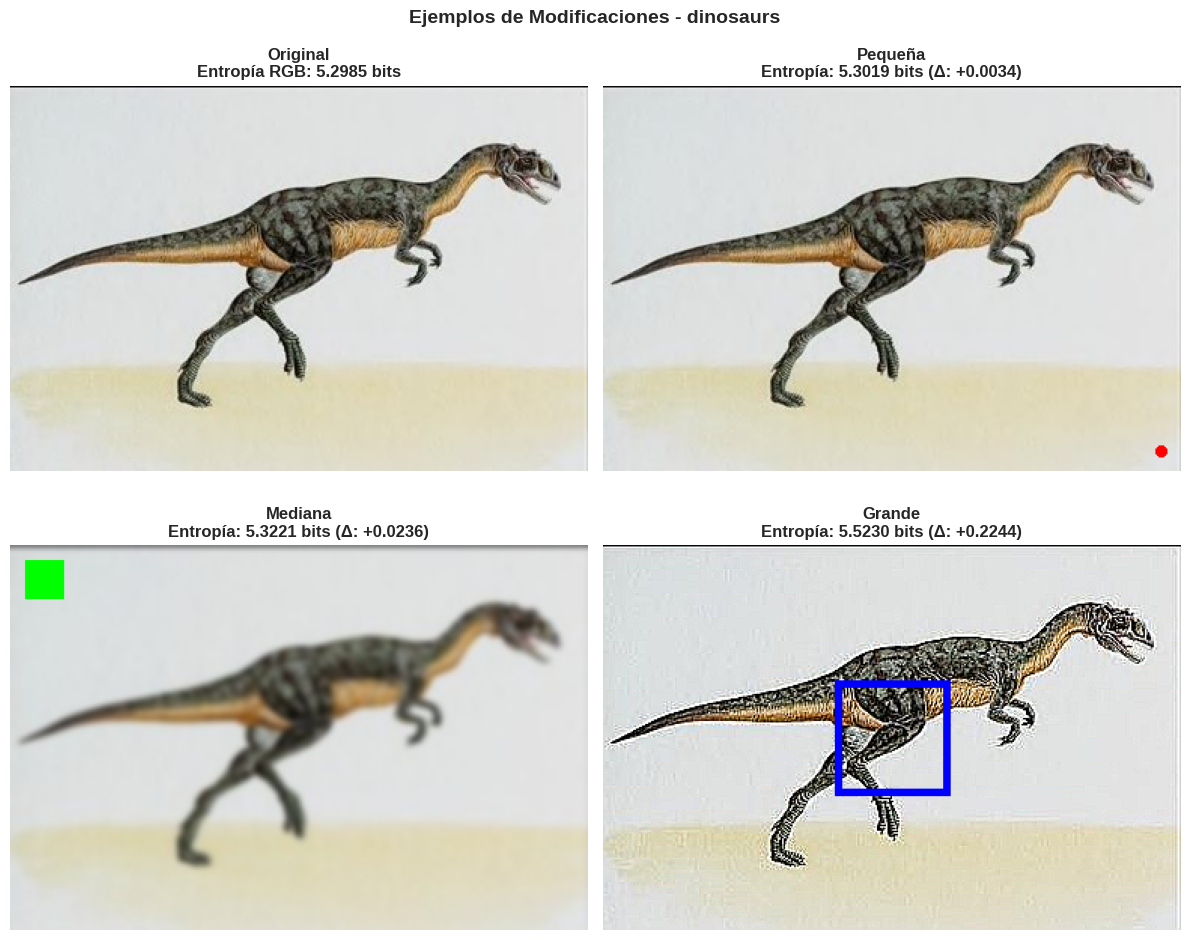

Ejemplos de modificaciones visualizados y guardados.


In [76]:
example_category, example_img_info = images_to_modify[2]
example_img = example_img_info['image']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Ejemplos de Modificaciones - {example_category}', fontweight='bold', fontsize=14)

axes[0, 0].imshow(example_img)
entropy_orig = calculate_entropy_rgb(example_img)
axes[0, 0].set_title(f'Original\nEntropía RGB: {entropy_orig:.4f} bits', fontweight='bold')
axes[0, 0].axis('off')

small_mod = modify_image_small(example_img)
entropy_small = calculate_entropy_rgb(small_mod)
diff_small = entropy_small - entropy_orig
axes[0, 1].imshow(small_mod)
axes[0, 1].set_title(f'Pequeña\nEntropía: {entropy_small:.4f} bits (Δ: {diff_small:+.4f})', fontweight='bold')
axes[0, 1].axis('off')

medium_mod = modify_image_medium(example_img)
entropy_medium = calculate_entropy_rgb(medium_mod)
diff_medium = entropy_medium - entropy_orig
axes[1, 0].imshow(medium_mod)
axes[1, 0].set_title(f'Mediana\nEntropía: {entropy_medium:.4f} bits (Δ: {diff_medium:+.4f})', fontweight='bold')
axes[1, 0].axis('off')

large_mod = modify_image_large(example_img)
entropy_large = calculate_entropy_rgb(large_mod)
diff_large = entropy_large - entropy_orig
axes[1, 1].imshow(large_mod)
axes[1, 1].set_title(f'Grande\nEntropía: {entropy_large:.4f} bits (Δ: {diff_large:+.4f})', fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
ejemplo_path = os.path.join(FOLDERS['graphics'], 'ejemplos_modificaciones.png')
plt.savefig(ejemplo_path, dpi=300, bbox_inches='tight')
plt.show()

print("Ejemplos de modificaciones visualizados y guardados.")

## 17. Gráfico Comparativo: Cambios de Entropía

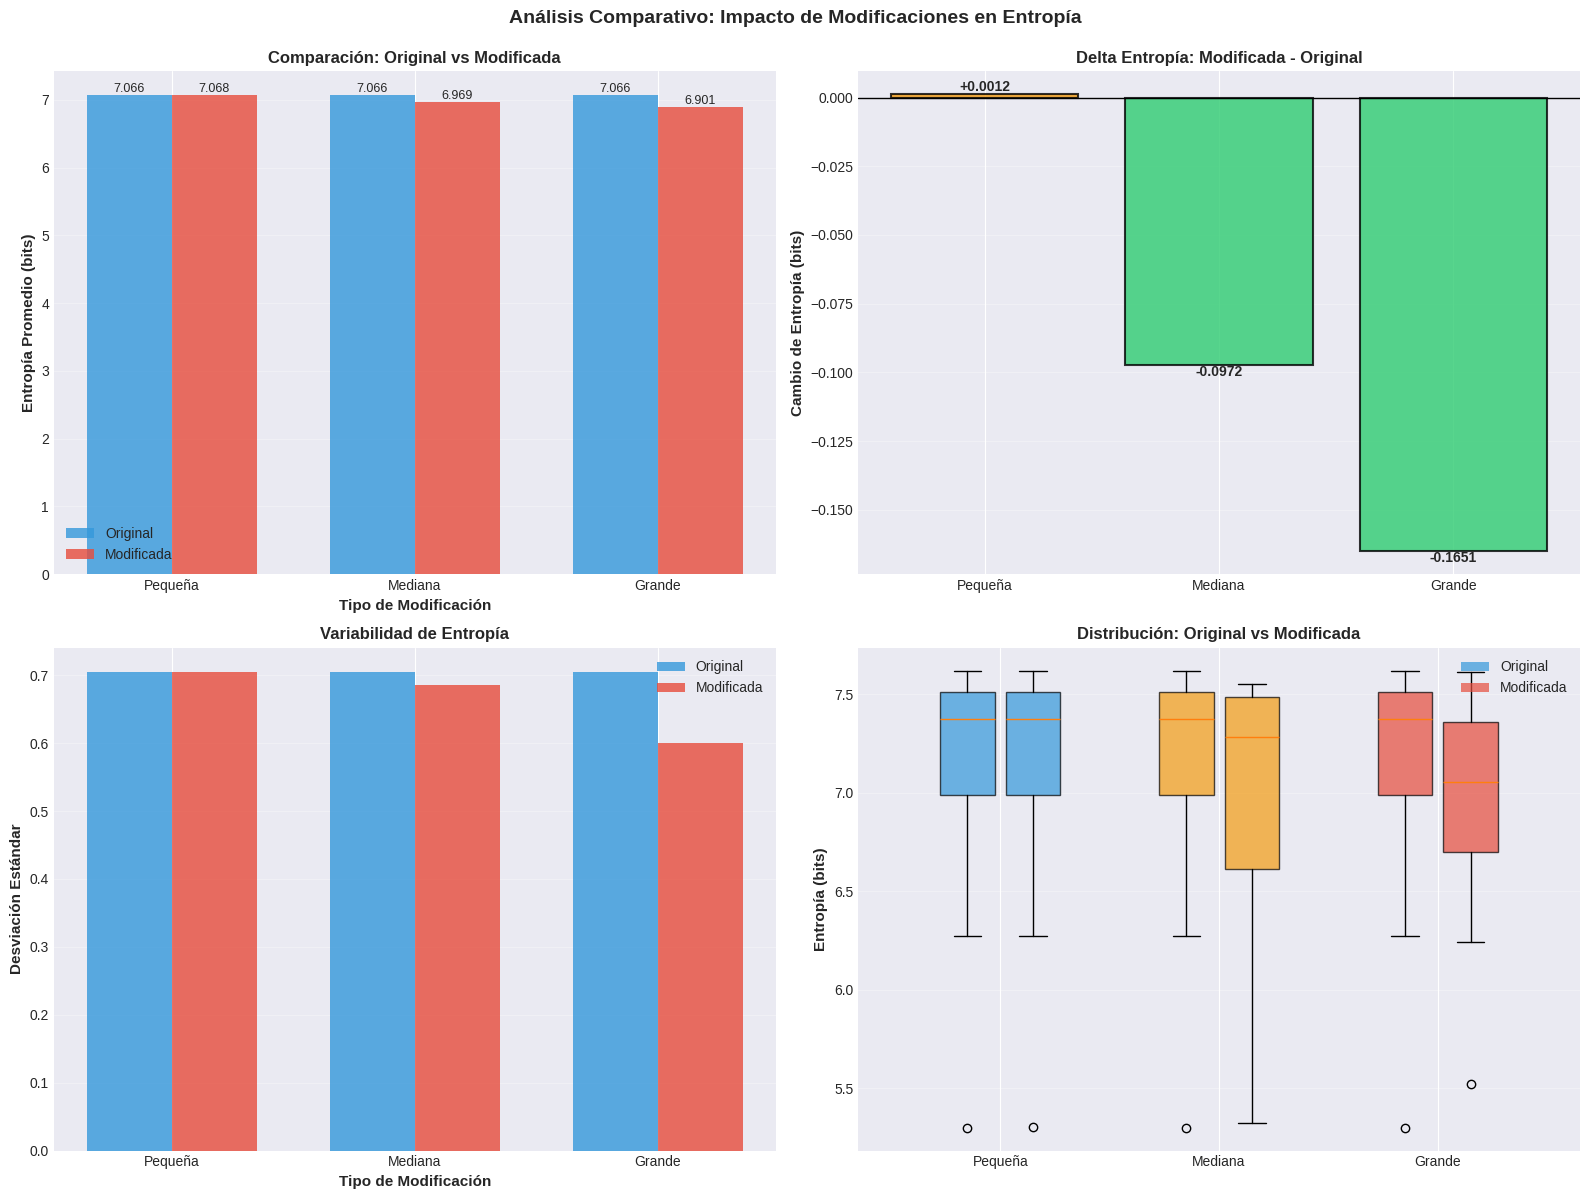

Gráfico comparativo generado y guardado.


In [77]:
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 2, figure=fig)

fig.suptitle('Análisis Comparativo: Impacto de Modificaciones en Entropía',
             fontsize=14, fontweight='bold', y=0.995)

ax1 = fig.add_subplot(gs[0, 0])

modifications = ['Pequeña', 'Mediana', 'Grande']
x_pos = np.arange(len(modifications))
width = 0.35

original_means = [np.mean(modifications_results[m]['original']) for m in ['small', 'medium', 'large']]
modified_means = [np.mean(modifications_results[m]['modified']) for m in ['small', 'medium', 'large']]

bars1 = ax1.bar(x_pos - width/2, original_means, width, label='Original', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, modified_means, width, label='Modificada', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('Tipo de Modificación', fontweight='bold')
ax1.set_ylabel('Entropía Promedio (bits)', fontweight='bold')
ax1.set_title('Comparación: Original vs Modificada', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(modifications)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])

differences_mean = [
    np.mean(modifications_results['small']['difference']),
    np.mean(modifications_results['medium']['difference']),
    np.mean(modifications_results['large']['difference'])
]

colors_diff = ['#2ecc71' if d < 0 else '#f39c12' for d in differences_mean]
bars_diff = ax2.bar(modifications, differences_mean, color=colors_diff, alpha=0.8, edgecolor='black', linewidth=1.5)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_ylabel('Cambio de Entropía (bits)', fontweight='bold')
ax2.set_title('Delta Entropía: Modificada - Original', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars_diff:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:+.4f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')

ax3 = fig.add_subplot(gs[1, 0])

original_stds = [
    np.std(modifications_results['small']['original']),
    np.std(modifications_results['medium']['original']),
    np.std(modifications_results['large']['original'])
]
modified_stds = [
    np.std(modifications_results['small']['modified']),
    np.std(modifications_results['medium']['modified']),
    np.std(modifications_results['large']['modified'])
]

bars3_1 = ax3.bar(x_pos - width/2, original_stds, width, label='Original', color='#3498db', alpha=0.8)
bars3_2 = ax3.bar(x_pos + width/2, modified_stds, width, label='Modificada', color='#e74c3c', alpha=0.8)

ax3.set_xlabel('Tipo de Modificación', fontweight='bold')
ax3.set_ylabel('Desviación Estándar', fontweight='bold')
ax3.set_title('Variabilidad de Entropía', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(modifications)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

ax4 = fig.add_subplot(gs[1, 1])

colors_mod = {'small': '#3498db', 'medium': '#f39c12', 'large': '#e74c3c'}

positions = [1, 1.3, 2, 2.3, 3, 3.3]
all_data = []
colors_list = []

for mod_type in ['small', 'medium', 'large']:
    original = modifications_results[mod_type]['original']
    modified = modifications_results[mod_type]['modified']
    all_data.append(original)
    all_data.append(modified)
    colors_list.extend([colors_mod[mod_type], colors_mod[mod_type]])

bp = ax4.boxplot(all_data, positions=positions, widths=0.25, patch_artist=True)

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_xticks([1.15, 2.15, 3.15])
ax4.set_xticklabels(['Pequeña', 'Mediana', 'Grande'])
ax4.set_ylabel('Entropía (bits)', fontweight='bold')
ax4.set_title('Distribución: Original vs Modificada', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', alpha=0.7, label='Original'),
    Patch(facecolor='#e74c3c', alpha=0.7, label='Modificada')
]
ax4.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
comparacion_path = os.path.join(FOLDERS['graphics'], 'comparacion_modificaciones.png')
plt.savefig(comparacion_path, dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico comparativo generado y guardado.")

## 18. Generación de Informe HTML Automatizado

In [78]:
def generate_html_report():
    """Genera un informe HTML simple y completo con resultados"""

    df_ranked_html = df_stats.sort_values('Entropía RGB (Media)', ascending=False)
    max_cat = df_ranked_html.iloc[0]['Categoría']
    min_cat = df_ranked_html.iloc[-1]['Categoría']
    max_entropy_val = df_ranked_html.iloc[0]['Entropía RGB (Media)']
    min_entropy_val = df_ranked_html.iloc[-1]['Entropía RGB (Media)']

    stats_table_html = df_stats.to_html(classes='stats-table', index=False)
    stats_table_html = stats_table_html.replace(
        '<table border="1" class="dataframe stats-table">',
        '<table class="stats-table">'
    )

    modifications_mean_small = np.mean(modifications_results['small']['difference'])
    modifications_mean_medium = np.mean(modifications_results['medium']['difference'])
    modifications_mean_large = np.mean(modifications_results['large']['difference'])

    html_content = f"""<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Informe: Análisis de Entropía en Imágenes</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 20px;
            line-height: 1.6;
            color: #333;
        }}
        .container {{
            max-width: 1000px;
            margin: 0 auto;
            padding: 20px;
        }}
        header {{
            text-align: center;
            margin-bottom: 30px;
            border-bottom: 1px solid #999;
            padding-bottom: 15px;
        }}
        h1 {{
            color: #000;
            margin: 0;
        }}
        .institution {{
            color: #666;
            font-size: 0.95em;
            margin: 5px 0;
        }}
        section {{
            margin: 30px 0;
            padding: 15px;
            border-left: 3px solid #666;
        }}
        h2 {{
            color: #000;
            margin-top: 0;
        }}
        h3 {{
            color: #333;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 15px 0;
            font-size: 0.9em;
        }}
        th {{
            background-color: #ddd;
            padding: 10px;
            text-align: left;
            border: 1px solid #999;
            font-weight: bold;
        }}
        td {{
            padding: 8px;
            border: 1px solid #999;
        }}
        tr:nth-child(even) {{
            background-color: #f9f9f9;
        }}
        .image-section {{
            margin: 20px 0;
            text-align: center;
        }}
        .image-section img {{
            max-width: 100%;
            height: auto;
            border: 1px solid #ccc;
            margin: 10px 0;
        }}
        .image-caption {{
            font-size: 0.9em;
            color: #666;
            margin-top: 5px;
        }}
        p {{
            text-align: justify;
        }}
        footer {{
            text-align: center;
            margin-top: 30px;
            border-top: 1px solid #999;
            padding-top: 15px;
            color: #666;
            font-size: 0.9em;
        }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>Análisis de Entropía en Imágenes</h1>
            <p class="institution">GIATA - Grupo de Investigación en Análisis de Información y Tratamiento Automático</p>
            <p class="institution">Universidad Politécnica Salesiana - Ecuador</p>
            <p class="institution">Generado: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}</p>
        </header>

        <section>
            <h2>Introducción</h2>
            <p>Este informe presenta los resultados del análisis de entropía realizado sobre 900 imágenes organizadas en 10 categorías. Se calculó la entropía en escala de grises y en color (RGB), se realizaron modificaciones en tres niveles y se generaron visualizaciones para el análisis comparativo.</p>
        </section>

        <section>
            <h2>Marco Teórico</h2>
            <h3>¿Qué es la Entropía?</h3>
            <p>La entropía es una medida de la incertidumbre o desorden en los datos. En el contexto de imágenes, cuantifica la variabilidad de los valores de píxeles. Se calcula usando la fórmula de Shannon: H = -Σ(p·log₂(p)), donde p es la probabilidad de cada valor de píxel.</p>
            <h3>Entropía en Escala de Grises</h3>
            <p>Considera un único canal de intensidad (0-255). Valores altos indican mayor variabilidad de luminosidad.</p>
            <h3>Entropía en Color (RGB)</h3>
            <p>Se calcula la entropía de cada canal (Rojo, Verde, Azul) independientemente y se promedian. Generalmente es mayor que en escala de grises debido a la información adicional de color.</p>
        </section>

        <section>
            <h2>Datos y Estadísticas</h2>
            <p><strong>Total de imágenes procesadas:</strong> {total_images}</p>
            <p><strong>Categorías analizadas:</strong> {len(images_data)}</p>
            
            <h3>Tabla de Estadísticas por Categoría</h3>
            {stats_table_html}
            
            <h3>Análisis de Categorías</h3>
            <p><strong>Categoría con Mayor Entropía:</strong> {max_cat} ({max_entropy_val:.4f} bits)</p>
            <p>Las imágenes de esta categoría presentan mayor complejidad visual y variabilidad de colores.</p>
            
            <p><strong>Categoría con Menor Entropía:</strong> {min_cat} ({min_entropy_val:.4f} bits)</p>
            <p>Las imágenes de esta categoría son más uniformes y tienen menor variabilidad cromática.</p>
        </section>

        <section>
            <h2>Visualizaciones de Ejemplos</h2>
            <div class="image-section">
                <img src="../images_originales/ejemplos_por_categoria.png" alt="Ejemplos de imágenes por categoría" style="max-width: 90%;">
                <p class="image-caption">Ejemplos representativos de cada categoría</p>
            </div>
        </section>

        <section>
            <h2>Histogramas de Ejemplo</h2>
            <div class="image-section">
                <img src="../histogramas/03_dinosaurs_histogramas.png" alt="Histogramas de ejemplo" style="max-width: 90%;">
                <p class="image-caption">Histogramas en escala de grises y canales RGB de ejemplo</p>
            </div>
        </section>

        <section>
            <h2>Distribución de Entropía por Categoría</h2>
            <div class="image-section">
                <img src="../graficos/boxplots_por_categoria.png" alt="Boxplots de entropía" style="max-width: 100%;">
                <p class="image-caption">Diagramas de cajas y bigotes para escala de grises y RGB</p>
            </div>
        </section>

        <section>
            <h2>Modificación de Imágenes</h2>
            <p>Se aplicaron tres niveles de modificación a {len(images_to_modify)} imágenes:</p>
            <ul>
                <li><strong>Pequeña (~1%):</strong> Se agregó un pequeño círculo rojo. Cambio promedio: {modifications_mean_small:+.4f} bits</li>
                <li><strong>Mediana (~10%):</strong> Se aplicó un filtro de desenfoque y se agregó un rectángulo verde. Cambio promedio: {modifications_mean_medium:+.4f} bits</li>
                <li><strong>Grande (~20%):</strong> Se aplicó un filtro de detección de bordes y se agregó un rectángulo azul. Cambio promedio: {modifications_mean_large:+.4f} bits</li>
            </ul>

            <div class="image-section">
                <img src="../graficos/ejemplos_modificaciones.png" alt="Ejemplos de modificaciones" style="max-width: 100%;">
                <p class="image-caption">Ejemplo de una imagen original y sus tres versiones modificadas</p>
            </div>
        </section>

        <section>
            <h2>Análisis Comparativo de Modificaciones</h2>
            <div class="image-section">
                <img src="../graficos/comparacion_modificaciones.png" alt="Comparación de modificaciones" style="max-width: 100%;">
                <p class="image-caption">Gráficos comparativos mostrando el impacto de las modificaciones en entropía</p>
            </div>
        </section>

        <section>
            <h2>Conclusiones</h2>
            <ul>
                <li>La entropía en color (RGB) es consistentemente mayor que en escala de grises.</li>
                <li>Existen diferencias significativas en entropía entre las diferentes categorías de imágenes.</li>
                <li>Las modificaciones pequeñas producen cambios mínimos en entropía, mientras que las grandes generan cambios más pronunciados.</li>
                <li>La relación entre cambio visual y cambio de entropía varía según el tipo de modificación aplicada.</li>
            </ul>
        </section>

        <footer>
            <p>Informe generado automáticamente</p>
            <p>Universidad Politécnica Salesiana - Ecuador</p>
        </footer>
    </div>
</body>
</html>"""

    return html_content

In [79]:
html_report = generate_html_report()

report_path = os.path.join(FOLDERS['reports'], 'Informe_Entropia.html')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html_report)

print(f"Informe HTML generado exitosamente en: {report_path}")

Informe HTML generado exitosamente en: /home/jordyr/Desktop/Practica0/output/reportes/Informe_Entropia.html


## 19. Resumen Final y Estructura de Carpetas

In [80]:
print("="*80)
print("RESUMEN FINAL DEL PROYECTO")
print("="*80)

print(f"\nDirectorio base: {BASE_DIR}")
print(f"\nEstructura de carpetas generada:")

for folder_type, folder_path in sorted(FOLDERS.items()):
    if os.path.exists(folder_path):
        file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        print(f"  {folder_path:55s} [{file_count:3d} archivos]")

print(f"\nResultados principales:")
print(f"  - Total de imágenes procesadas: {total_images}")
print(f"  - Categorías analizadas: {len(images_data)}")
print(f"  - Imágenes modificadas: {len(images_to_modify)}")
print(f"  - Modificaciones por imagen: 3 (pequeña, mediana, grande)")
print(f"  - Total de imágenes modificadas guardadas: {len(images_to_modify) * 3}")
print(f"  - Gráficos generados: 2 principales + histogramas de ejemplo")
print(f"  - Informe HTML: 1 (en carpeta 'reportes')")

print(f"\n" + "="*80)
print("PROYECTO COMPLETADO EXITOSAMENTE")
print("="*80)
print(f"\nTodos los resultados están organizados en: {OUTPUT_DIR}")
print(f"Informe HTML disponible en: {report_path}")

RESUMEN FINAL DEL PROYECTO

Directorio base: /home/jordyr/Desktop/Practica0

Estructura de carpetas generada:
  /home/jordyr/Desktop/Practica0/output/graficos          [  3 archivos]
  /home/jordyr/Desktop/Practica0/output/histogramas       [  3 archivos]
  /home/jordyr/Desktop/Practica0/output/modificaciones/grandes [ 10 archivos]
  /home/jordyr/Desktop/Practica0/output/modificaciones/medianas [ 10 archivos]
  /home/jordyr/Desktop/Practica0/output/images_originales [  1 archivos]
  /home/jordyr/Desktop/Practica0/output/reportes          [  1 archivos]
  /home/jordyr/Desktop/Practica0/output/modificaciones/pequenas [ 10 archivos]

Resultados principales:
  - Total de imágenes procesadas: 900
  - Categorías analizadas: 10
  - Imágenes modificadas: 10
  - Modificaciones por imagen: 3 (pequeña, mediana, grande)
  - Total de imágenes modificadas guardadas: 30
  - Gráficos generados: 2 principales + histogramas de ejemplo
  - Informe HTML: 1 (en carpeta 'reportes')

PROYECTO COMPLETADO EXIT